# Inspect Class Imbalance — PlantDocAI

This notebook inspects the dataset organization used by PlantDocAI and computes per-class sample counts to identify low-sample classes. It automatically uses the project's `configs/baseline.yaml` if present and respects `data/splits/*` (CSV) when available.

Goal:
- Read dataset and split configuration from project.
- Count samples per class (per-split if splits exist and total).
- Identify low-sample classes by configurable criteria.
- Provide tables and visualizations for quick inspection.

## Imports and helper utilities

Run the cell below to import the libraries used by this notebook. The code tries to avoid unnecessary external YAML dependencies by parsing the small config file with a simple extractor. If you prefer to use `pyyaml`, install it and replace the parsing logic.

In [1]:
import os
import re
from pathlib import Path
from collections import Counter
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Notebook utility functions
def parse_simple_yaml(path, keys):
    '''Very small helper to extract simple string values from a YAML-like file.
    Returns dict of key->value for keys found (without quotes). This intentionally avoids adding a YAML dependency.
    '''
    out = {}
    if not os.path.isfile(path):
        return out
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            for k in keys:
                if line.startswith(k + ':'):
                    # capture after colon, strip spaces and surrounding quotes
                    val = line.split(':', 1)[1].strip()
                    if (val.startswith('')) or (val.startswith() and val.endswith()):
                        val = val[1:-1]
                    out[k] = val
    return out

def read_split_csv(csv_path):
    rows = []
    if not os.path.isfile(csv_path):
        return rows
    with open(csv_path, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(r)
    return rows

def scan_class_folders(root_dir):
    root = Path(root_dir)
    if not root.exists() or not root.is_dir():
        raise FileNotFoundError(f'Root data directory not found: {root_dir}')
    classes = []
    for p in sorted(root.iterdir()):
        if p.is_dir() and not p.name.startswith('.'):
            classes.append(p.name)
    return classes

## Locate data and splits using project conventions

This project defines `dataDir` and `splitDir` in `configs/baseline.yaml`. We'll read them if present; otherwise fallback to `data/PlantVillage/train` and `data/splits` relative to the repo root.

In [2]:
# Determine project root (assume notebook lives inside the project workspace)
proj_root = Path('..').resolve() if (Path('..') / 'README.md').exists() else Path('.').resolve()
# More robust: find repository root by climbing until we find README.md or .git or 'configs' folder
def find_repo_root(start=Path('.')):
    cur = start.resolve()
    for _ in range(8):
        if (cur / 'README.md').exists() or (cur / 'configs').exists() or (cur / '.git').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

repo_root = find_repo_root(Path('.'))
print('Repository root detected as:', repo_root)

# Try parsing configs/baseline.yaml for dataDir and splitDir
cfg_path = repo_root / 'configs' / 'baseline.yaml'
cfg = parse_simple_yaml(str(cfg_path), ['dataDir', 'splitDir'])
data_dir = (repo_root / cfg.get('dataDir', 'data/PlantVillage/train')).as_posix()
split_dir = (repo_root / cfg.get('splitDir', 'data/splits')).as_posix()

print('Using data directory:', data_dir)
print('Using split directory:', split_dir)

Repository root detected as: D:\AI\PlantDocAI
Using data directory: D:/AI/PlantDocAI/data/extended/train
Using split directory: D:/AI/PlantDocAI/data/splits


## Load counts per class

Logic:
- If `split_dir` contains `train.csv`/`val.csv`/`test.csv` and `classes.csv`, we'll load splits and compute per-split counts then aggregate totals.
- Otherwise, we fall back to scanning class folders under `data_dir` and counting image files.

In [3]:
# Helper: load classes mapping if present in split_dir/classes.csv
def load_classes_csv(classes_csv):
    if not os.path.isfile(classes_csv):
        return {}
    df = pd.read_csv(classes_csv)
    return dict(zip(df['labelId'], df['className']))

classes_csv = Path(split_dir) / 'classes.csv'
classid_to_name = load_classes_csv(str(classes_csv))
use_splits = (Path(split_dir) / 'train.csv').exists() and (Path(split_dir) / 'val.csv').exists() and (Path(split_dir) / 'test.csv').exists()

print('classes.csv found:', classes_csv.exists())
print('Using split CSVs:', use_splits)

# Compute counts
per_split_counts = {}
if use_splits:
    for split in ['train', 'val', 'test']:
        rows = read_split_csv(str(Path(split_dir) / f'{split}.csv'))
        c = Counter()
        for r in rows:
            # labelId is numeric; keep consistent types
            lid = int(r['labelId'])
            c[lid] += 1
        per_split_counts[split] = c
else:
    # fallback: scan class folders and count image files
    classes = scan_class_folders(data_dir)
    c = Counter()
    for cls in classes:
        cls_dir = Path(data_dir) / cls
        cnt = 0
        for root, _, files in os.walk(cls_dir):
            for fn in files:
                if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                    cnt += 1
        c[cls] = cnt
    per_split_counts['folders'] = c

# Build a DataFrame of results
if use_splits:
    # Get set of all label ids present in classes.csv or in splits
    all_label_ids = set()
    for spc in per_split_counts.values():
        all_label_ids.update(spc.keys())
    rows = []
    for lid in sorted(all_label_ids):
        name = classid_to_name.get(lid, f'label_{lid}')
        t = per_split_counts['train'].get(lid, 0)
        v = per_split_counts['val'].get(lid, 0)
        te = per_split_counts['test'].get(lid, 0)
        total = t + v + te
        rows.append({'labelId': lid, 'className': name, 'train': t, 'val': v, 'test': te, 'total': total})
    df_counts = pd.DataFrame(rows).sort_values('total', ascending=True).reset_index(drop=True)
else:
    # per folder counts keyed by class name
    rows = []
    for cls, cnt in per_split_counts['folders'].items():
        rows.append({'className': cls, 'total': int(cnt)})
    df_counts = pd.DataFrame(rows).sort_values('total', ascending=True).reset_index(drop=True)

print('Built counts table with', len(df_counts), 'rows')
df_counts.head(20)

classes.csv found: True
Using split CSVs: True
Built counts table with 38 rows


,labelId,className,train,val,test,total
0,23,Raspberry___healthy,238,30,29,297
1,36,Tomato___Tomato_mosaic_virus,239,30,30,299
2,1,Apple___Black_rot,397,50,49,496
3,17,Peach___healthy,481,60,60,601
4,6,Cherry_(including_sour)___healthy,547,69,68,684
5,31,Tomato___Leaf_Mold,609,76,76,761
6,9,Corn_(maize)___Northern_Leaf_Blight,630,79,79,788
7,18,"Pepper,_bell___Bacterial_spot",638,80,79,797
8,20,Potato___Early_blight,640,80,80,800
9,29,Tomato___Early_blight,640,80,80,800


## Summary statistics and low-sample detection criteria

We compute general statistics (total classes, total samples, mean, median) and flag low-sample classes using three user-configurable criteria:
- `threshold_abs`: absolute sample count threshold (e.g., classes with fewer than 50 samples).
- `threshold_rel`: classes with total < (median * rel_factor) (e.g., rel_factor=0.5 means below half the median).
- `top_n`: show the bottom N classes by count.
You can adjust these values below.

In [4]:
# Configurable thresholds
threshold_abs = 50
rel_factor = 0.5
top_n = 10

# Compute stats
if 'total' not in df_counts.columns:
    pass
total_samples = int(df_counts['total'].sum())
num_classes = len(df_counts)
mean_count = float(df_counts['total'].mean())
median_count = float(df_counts['total'].median())
min_count = int(df_counts['total'].min())
max_count = int(df_counts['total'].max())

print(f'Total samples: {total_samples}')
print(f'Number of classes: {num_classes}')
print(f'Mean samples/class: {mean_count:.2f}')
print(f'Median samples/class: {median_count:.2f}')
print(f'Min / Max samples per class: {min_count} / {max_count}')

# Identify low-sample classes by criteria
low_abs = df_counts[df_counts['total'] < threshold_abs] if 'total' in df_counts.columns else pd.DataFrame()
low_rel = df_counts[df_counts['total'] < (median_count * rel_factor)] if 'total' in df_counts.columns else pd.DataFrame()
bottom_n = df_counts.nsmallest(top_n, 'total') if 'total' in df_counts.columns else pd.DataFrame()

print('Classes with total <', threshold_abs, ':', len(low_abs))
print('Classes with total < median *', rel_factor, ':', len(low_rel))
print('Bottom', top_n, 'classes by total:')
bottom_n[['className', 'total']]

Total samples: 47501
Number of classes: 38
Mean samples/class: 1250.03
Median samples/class: 948.50
Min / Max samples per class: 297 / 4405
Classes with total < 50 : 0
Classes with total < median * 0.5 : 2
Bottom 10 classes by total:


,className,total
0,Raspberry___healthy,297
1,Tomato___Tomato_mosaic_virus,299
2,Apple___Black_rot,496
3,Peach___healthy,601
4,Cherry_(including_sour)___healthy,684
5,Tomato___Leaf_Mold,761
6,Corn_(maize)___Northern_Leaf_Blight,788
7,"Pepper,_bell___Bacterial_spot",797
8,Potato___Early_blight,800
9,Tomato___Early_blight,800


## Visualizations

- Full-class bar plot (if class count is small).
- Otherwise, plot bottom N classes and distribution summary.

C:\temp\ipykernel_75780\922403647.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom, x='total', y='className', palette='magma')


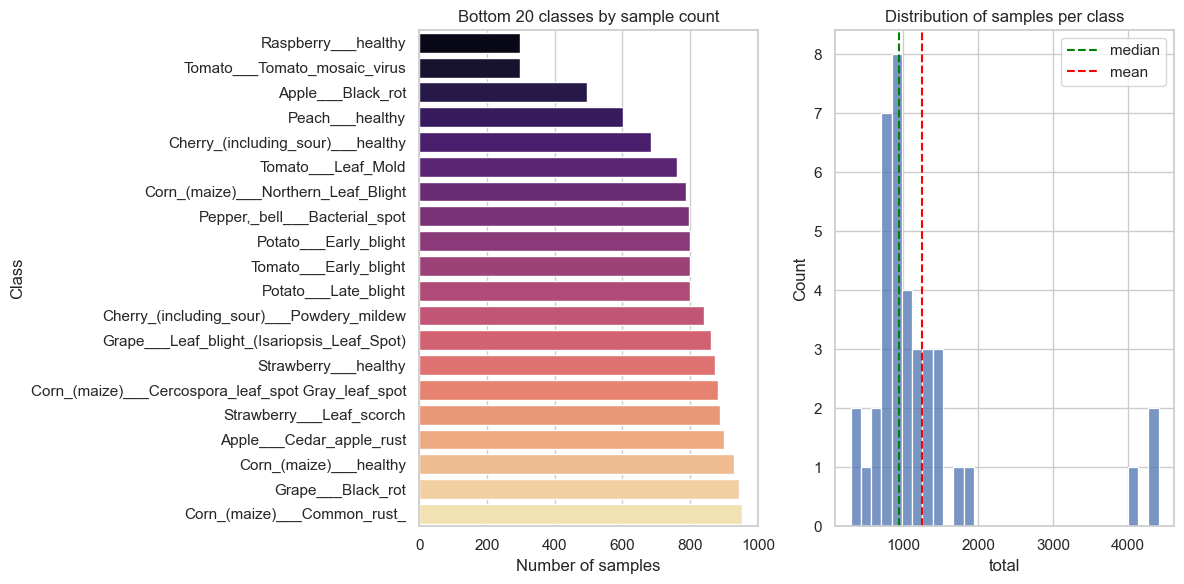

In [5]:
plt.figure(figsize=(12, 6))
if num_classes <= 30:
    # plot all classes
    sns.barplot(data=df_counts, x='total', y='className', palette='viridis')
    plt.title('Samples per class (all classes)')
    plt.xlabel('Number of samples')
    plt.ylabel('Class')
else:
    # plot bottom N and a separate histogram
    bottom = df_counts.nsmallest(20, 'total')
    plt.subplot(1, 2, 1)
    sns.barplot(data=bottom, x='total', y='className', palette='magma')
    plt.title('Bottom 20 classes by sample count')
    plt.xlabel('Number of samples')
    plt.ylabel('Class')

    plt.subplot(1, 2, 2)
    sns.histplot(df_counts['total'], bins=30, kde=False)
    plt.axvline(median_count, color='green', linestyle='--', label='median')
    plt.axvline(mean_count, color='red', linestyle='--', label='mean')
    plt.legend()
    plt.title('Distribution of samples per class')

plt.tight_layout()
plt.show()

## Recommendations & Conclusion

- Use the `low_abs` and `low_rel` lists to decide whether to augment or merge classes before training.
- Classes flagged by both absolute and relative criteria are high-risk for poor generalization.
- If using stratified sampling or class-aware batching, consider these counts when setting sampling weights.

The section below prints concise recommendations and a short summary table.

In [6]:
import pandas as pd

# Chuẩn hóa dữ liệu
df_counts = df_counts.copy()
df_counts["total"] = pd.to_numeric(df_counts["total"], errors="coerce")
df_counts = df_counts.dropna(subset=["total"])
df_counts["total"] = df_counts["total"].astype(int)

# Tham số
threshold_abs = 50
rel_factor = 0.5
bottom_n = 10

# Tính các nhóm lớp ít mẫu
low_abs = df_counts[df_counts["total"] < threshold_abs]
median_count = df_counts["total"].median()
low_rel = df_counts[df_counts["total"] < median_count * rel_factor]

def summarize_findings(df_counts, low_abs, low_rel, bottom_n):
    print('--- Summary ---')
    print(f'Total classes: {len(df_counts)}')
    print(f'Total samples: {int(df_counts["total"].sum())}')
    print(f'Classes below absolute threshold ({threshold_abs}): {len(low_abs)}')
    print(f'Classes below relative threshold (median * {rel_factor}): {len(low_rel)}')

    print('\nBottom classes:')
    display(df_counts.nsmallest(bottom_n, "total")[["className", "total"]])

    if len(low_abs) > 0:
        print('\nClasses below absolute threshold:')
        display(low_abs[["className", "total"]])

    if len(low_rel) > 0:
        print('\nClasses below relative threshold:')
        display(low_rel[["className", "total"]])

    if len(low_abs) > 0 or len(low_rel) > 0:
        print('\nSuggested action: consider data augmentation, resampling, or class-merging analysis for the classes above.')

summarize_findings(df_counts, low_abs, low_rel, bottom_n)

--- Summary ---
Total classes: 38
Total samples: 47501
Classes below absolute threshold (50): 0
Classes below relative threshold (median * 0.5): 2

Bottom classes:


,className,total
0,Raspberry___healthy,297
1,Tomato___Tomato_mosaic_virus,299
2,Apple___Black_rot,496
3,Peach___healthy,601
4,Cherry_(including_sour)___healthy,684
5,Tomato___Leaf_Mold,761
6,Corn_(maize)___Northern_Leaf_Blight,788
7,"Pepper,_bell___Bacterial_spot",797
8,Potato___Early_blight,800
9,Tomato___Early_blight,800



Classes below relative threshold:


,className,total
0,Raspberry___healthy,297
1,Tomato___Tomato_mosaic_virus,299



Suggested action: consider data augmentation, resampling, or class-merging analysis for the classes above.


In [7]:
# Build suggestion report and export CSV (priority: high->medium->low).
from pathlib import Path
# Ensure df_counts exists and has 'total'
report_df = df_counts[["className", "total"]].copy()
median_val = int(report_df['total'].median())
# Target rule: if total < 1000 -> target 1000; elif total < median -> target = median; else target = total
def compute_target(total):
    if total < 1000:
        return 1000
    if total < median_val:
        return median_val
    return total
report_df['target'] = report_df['total'].apply(compute_target)
report_df['need'] = report_df['target'] - report_df['total']
# priority score: high (3) if need >=400, medium (2) if need >=200, low (1) if need>0 else 0
def score_need(n):
    if n <= 0:
        return 0
    if n >= 400:
        return 3
    if n >= 200:
        return 2
    return 1
report_df['priority_score'] = report_df['need'].apply(score_need)
report_df['priority'] = report_df['priority_score'].map({3: 'high', 2: 'medium', 1: 'low', 0: 'none'})
# split suggested additions into train/val (80/20) to keep similar ratios to existing splits
report_df['add_train'] = (report_df['need'] * 0.8).round().astype(int)
report_df['add_val'] = (report_df['need'] - report_df['add_train']).astype(int)
# Filter only classes needing addition and sort by priority (high->low) then need desc
suggest = report_df[report_df['need'] > 0].sort_values(['priority_score', 'need'], ascending=[False, False])
# Prepare output path and ensure artifacts folder exists
out_dir = Path(repo_root) / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'low_sample_suggestions.csv'
suggest_out = suggest[['className', 'total', 'target', 'need', 'priority', 'add_train', 'add_val']]
suggest_out.to_csv(out_path, index=False, encoding='utf-8')
print(f'Wrote low-sample suggestions to: {out_path}')
# Display the suggestion table
from IPython.display import display
display(suggest_out.reset_index(drop=True))

Wrote low-sample suggestions to: D:\AI\PlantDocAI\artifacts\low_sample_suggestions.csv


,className,total,target,need,priority,add_train,add_val
0,Raspberry___healthy,297,1000,703,high,562,141
1,Tomato___Tomato_mosaic_virus,299,1000,701,high,561,140
2,Apple___Black_rot,496,1000,504,high,403,101
3,Peach___healthy,601,1000,399,medium,319,80
4,Cherry_(including_sour)___healthy,684,1000,316,medium,253,63
5,Tomato___Leaf_Mold,761,1000,239,medium,191,48
6,Corn_(maize)___Northern_Leaf_Blight,788,1000,212,medium,170,42
7,"Pepper,_bell___Bacterial_spot",797,1000,203,medium,162,41
8,Potato___Early_blight,800,1000,200,medium,160,40
9,Tomato___Early_blight,800,1000,200,medium,160,40


---
Notebook created to be reusable: adjust `threshold_abs`, `rel_factor` and `top_n` near the top to tune sensitivity.

If you'd like, I can: generate a CSV report of low-sample classes, or add automatic augmentation suggestions per-class.